[1] Loading and Scaling a_im...
[2] Extrapolating a_im to 1/zeta_hat -> 0...


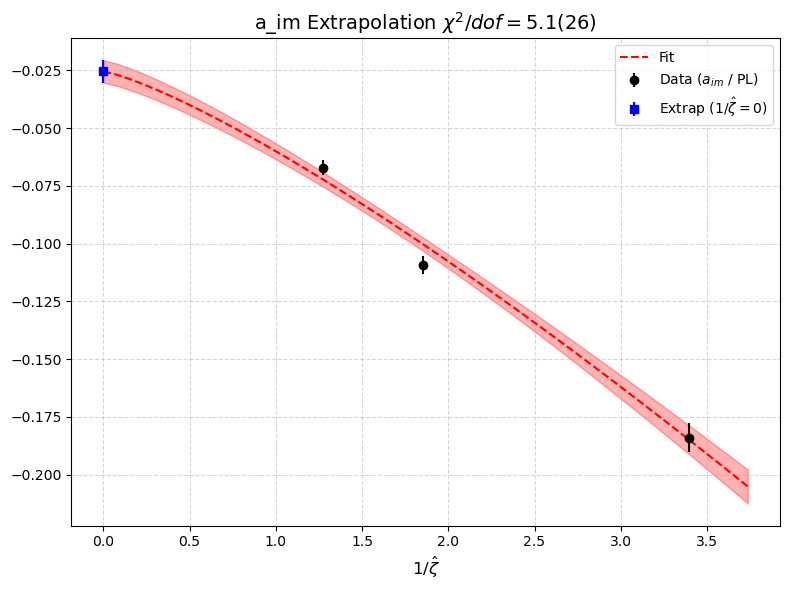

In [5]:
import h5py
import numpy as np
import math
import gvar as gv
import lsqfit
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Helpers & Statistics
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    if err <= 0: return f"{mean}"
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
    else:
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1)) 
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"

def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
    return fitted_params


power = 1.25
# ---------------------------------------------------------
# 2. Extrapolation Routine for Parameters
# ---------------------------------------------------------
def fit_param_linear(inv_zeta_vals, param_jk_samples):
    """
    Fits y = c0 + c1 * (1/zeta_hat)^2 for a given parameter.
    """
    N_PL, N_JK = param_jk_samples.shape

    mean_y = np.mean(param_jk_samples, axis=1)
    cov_y = np.cov(param_jk_samples, bias=True) * (N_JK - 1)

    try:
        y_gvar = gv.gvar(mean_y, cov_y)
    except Exception:
        y_gvar = gv.gvar(mean_y, np.sqrt(np.diag(cov_y)))

    # Fit in 1/zeta_hat^2
    def fcn(x, p):
        return p['c0'] + p['c1'] * x**(power)

    prior = {'c0': gv.gvar(0, 5), 'c1': gv.gvar(0, 5)}

    c0_jk = []
    c1_jk = []
    chi2_dof = []
    cov_y_eval = gv.evalcov(y_gvar)

    for k in range(N_JK):
        y_k_gvar = gv.gvar(param_jk_samples[:, k], cov_y_eval)
        fit_k = lsqfit.nonlinear_fit(data=(inv_zeta_vals, y_k_gvar), fcn=fcn, prior=prior)
        chi2_dof.append(fit_k.chi2 / fit_k.dof)
        c0_jk.append(fit_k.pmean['c0'])
        c1_jk.append(fit_k.pmean['c1'])

    return np.array(c0_jk), np.array(c1_jk), np.array(chi2_dof)

# ---------------------------------------------------------
# 3. Main Routine for a_im
# ---------------------------------------------------------
def extrapolate_a_im(PL_list, bminfit, etamin, etamax, b2=9.0):
    
    pl_to_zeta = {
        -4: 0.785756,
        -3: 0.539684,
        -2: 0.294367,
        -1: 0.090772
    }
    
    inv_zeta_vals = np.array([1.0 / pl_to_zeta[pl] for pl in PL_list])
    #inv_zeta_vals = np.array([1.0 / (-pl) for pl in PL_list])
    sort_idx = np.argsort(inv_zeta_vals)
    inv_zeta_vals = inv_zeta_vals[sort_idx]
    sorted_PL_list = [PL_list[i] for i in sort_idx]
    N_PL = len(sorted_PL_list)
    
    # Create dynamic PL string for filenames (e.g. [-2, -3, -4] -> "234")
    pl_str = "".join([str(abs(p)) for p in sorted(PL_list, reverse=True)])
    
    # Load Initial Data to get N_JK
    init_filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{sorted_PL_list[0]}.h5"
    init_params = load_params_from_h5(init_filename)
    N_JK = len(init_params['a_im'])

    # Array to hold the scaled a_im data
    a_im_raw = np.zeros((N_PL, N_JK))

    print("[1] Loading and Scaling a_im...")
    for i, pl in enumerate(sorted_PL_list):
        filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
        params = load_params_from_h5(filename)
        
        # Apply specific scaling rule for a_im
        a_im_raw[i, :] = params['a_im'] / pl

    print("[2] Extrapolating a_im to 1/zeta_hat -> 0...")
    c0_jk, c1_jk, chi2 = fit_param_linear(inv_zeta_vals, a_im_raw)
    
    # Plotting setup
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_x = np.linspace(0, max(inv_zeta_vals)*1.1, 50)

    # Get means and errors for the raw data points
    y_means = np.mean(a_im_raw, axis=1)
    y_errs = [Jackknife(a_im_raw[i, :])[1] for i in range(N_PL)]
    
    # Generate Error Band for the fit line
    fit_m = np.zeros(len(plot_x))
    fit_e = np.zeros(len(plot_x))
    for i_x, px in enumerate(plot_x):
        # Evaluate the linear fit at this x for all JK samples
        jk_vals_at_x = c0_jk + c1_jk * px**(power)
        fit_m[i_x], fit_e[i_x] = Jackknife(jk_vals_at_x)
    
    c0_m, c0_e = Jackknife(c0_jk)
    
    # Plotting
    ax.errorbar(inv_zeta_vals, y_means, yerr=y_errs, fmt='o', color='black', label='Data ($a_{im}$ / PL)')
    ax.plot(plot_x, fit_m, color='red', linestyle='--', label='Fit')
    ax.fill_between(plot_x, fit_m - fit_e, fit_m + fit_e, color='red', alpha=0.3)
    ax.errorbar([0], [c0_m], yerr=[c0_e], fmt='s', color='blue', label='Extrap ($1/\\hat{\\zeta} = 0$)')
    
    ax.set_title(f"a_im Extrapolation $\\chi^2/dof = {fmt_err(*Jackknife(chi2))}$", fontsize=14)
    ax.set_xlabel("$1/\\hat{\\zeta}$", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

    plt.tight_layout()
    plt.savefig(f"Param_Extrapolation_a_im_P{pl_str}_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf")
    plt.show()

    return c0_m, c0_e

# Example execution call:
c0_mean, c0_error = extrapolate_a_im([-2, -3, -4], bminfit=3, etamin=6, etamax=10)